# Week 5 Day 5 Lab


In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Recall: Eigenvalues

An eigenvector is a vector $v$ such that

$$Av=\lambda v.$$

where
- $A$ is a matrix
- $\lambda$ is a scalar (called the eigenvalue)



Suppose$
A=
\begin{bmatrix}
4 & 1\\
1 & 3
\end{bmatrix}$ Note that $A=A^T$. We call these matrices *symmetric*. We can compute the eigenvalues and eigenvectors as follows:

In [4]:
A = np.array([[4,1],[1,3]])
A @ np.linalg.eig(A)[1][:,1]

array([-1.25227364,  2.02622131])

In [5]:
np.linalg.eig(A)[0][1]*np.array([-0.52573111,  0.85065081])

array([-1.25227364,  2.02622132])

### Recall: Quadratic Forms

Consider

$$f(x)=x^TAx$$

This is called a **quadratic form**. If

```python
x = [x₁,x₂]
```
then

```python
A =
[[4,1],
 [1,3]]
```

gives $$f(x)=4x_1^2+2x_1x_2+3x_2^2.$$

Quadratic forms appear throughout optimization. Most importantly, in eigenvalues.

### The Rayleigh Quotient

The quantity

$$
R(A)=\frac{x^TAx}{x^Tx}
$$

is called the **Rayleigh Quotient**.

One of the most important theorems in linear algebra states

$$
\lambda_{\min}(A)\leq R(A)
\leq \lambda_{\max}(A)
$$

And that for symmetric matrices $\min_{x\neq 0}R(A)=\lambda_{\min}$ and $\max_{x\neq 0}R(A)=\lambda_{\max}$ where the $x$'s that acheive these values are the eigenvectors.

Consider drawing these randomly:

In [6]:
values, vectors = np.linalg.eig(A)

largest = np.max(values)

samples = []

for i in range(5000):
    x = np.random.randn(2)
    x = x/np.linalg.norm(x)

    value = x.T @ A @ x

    samples.append(value)

print(max(samples))
print(largest)

4.618032262870925
4.618033988749895


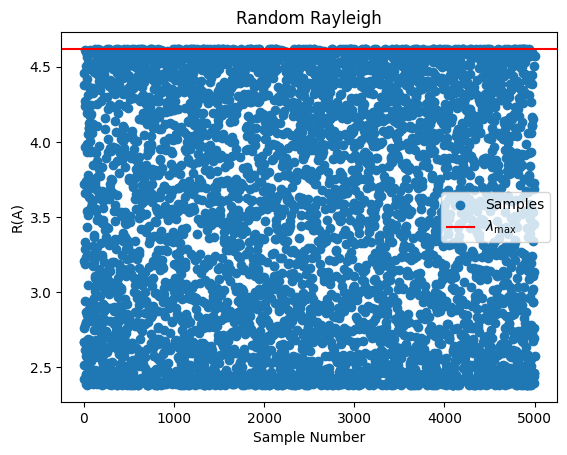

In [7]:
plt.scatter([i for i in range(len(samples))],samples,label='Samples')
plt.axhline(largest, color='red',label=r'$\lambda_{\max}$')
plt.xlabel('Sample Number')
plt.ylabel('R(A)')
plt.title('Random Rayleigh')
plt.legend()

### Problem  1
Write a function that uses `scipy.optimize` to find the largest and smallest eigenvalue of a symmetric two by two matrix.

In [13]:
from scipy.optimize import minimize

def rayleigh(x):
    x = x / np.linalg.norm(x)
    return x @ A @ x


def eigen_optimize(A):

    x0 = np.array([1.0, 0.0])
    x1 = np.array([0.0, 1.0])

    res_min = minimize(rayleigh, x0)

    res_max = minimize(lambda x: -rayleigh(x), x1)

    lambda_min = rayleigh(res_min.x)
    lambda_max = rayleigh(res_max.x)

    return lambda_min, lambda_max

A = np.array([[2, 1], [1, 3]])

lam_min, lam_max = eigen_optimize(A)

print("Smallest eigenvalue:", lam_min)
print("Largest eigenvalue:", lam_max)

# Compare with NumPy
print("NumPy:", np.linalg.eigvalsh(A))

Smallest eigenvalue: 1.3819660112501404
Largest eigenvalue: 3.6180339887498683
NumPy: [1.38196601 3.61803399]


### Problem 2
Write a function that randomly samples vectors to approximate the largest and smallest eigenvalues. Make this function print the error as well.

In [12]:
import numpy as np

def approx_eigenvalues(A, num_samples=10000):
    true_eigs = np.linalg.eigvalsh(A)
    true_min = true_eigs[0]
    true_max = true_eigs[-1]

    approx_min = np.inf
    approx_max = -np.inf

    for i in range(num_samples):
        x = np.random.randn(2)
        x = x / np.linalg.norm(x)

        rq = x @ A @ x

        approx_min = min(approx_min, rq)
        approx_max = max(approx_max, rq)

    print(f"Approximate smallest eigenvalue: {approx_min:.6f}")
    print(f"True smallest eigenvalue:        {true_min:.6f}")
    print(f"Error:                           {abs(approx_min - true_min):.6e}")

    print()

    print(f"Approximate largest eigenvalue:  {approx_max:.6f}")
    print(f"True largest eigenvalue:         {true_max:.6f}")
    print(f"Error:                           {abs(approx_max - true_max):.6e}")

    return approx_min, approx_max

A = np.array([[2, 1],
              [1, 3]])

approx_eigenvalues(A, 100000)

Approximate smallest eigenvalue: 1.381966
True smallest eigenvalue:        1.381966
Error:                           2.892939e-10

Approximate largest eigenvalue:  3.618034
True largest eigenvalue:         3.618034
Error:                           2.543903e-10


(np.float64(1.381966011539399), np.float64(3.6180339884955046))

### Problem 3
Generalize the function from Problem 1 for arbitrary sized matrices.

In [15]:
def eigen_optimize_2(A):
    n = A.shape[0]

    x0 = np.random.randn(n)
    x1 = np.random.randn(n)

    res_min = minimize(rayleigh, x0)
    res_max = minimize(lambda x: -rayleigh(x), x1)

    lambda_min = rayleigh(res_min.x)
    lambda_max = rayleigh(res_max.x)

    return lambda_min, lambda_max

A = np.array([[4, 1, 0], [1, 3, 1], [0, 1, 2]])

lam_min, lam_max = eigen_optimize_2(A)

print("Smallest eigenvalue:", lam_min)
print("Largest eigenvalue:", lam_max)

# Compare with NumPy
print("NumPy:", np.linalg.eigvalsh(A))

Smallest eigenvalue: 1.267949192441679
Largest eigenvalue: 4.7320508075677905
NumPy: [1.26794919 3.         4.73205081]
